In [1]:
# --- QUICK SETUP (run after fresh restart) --------------------
from pathlib import Path
import numpy as np
import seaborn as sns, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from collections import Counter

# paths
DATA_ROOT = Path(r"D:\NNDL\Dataset\DATASET")
TRAIN_DIR = DATA_ROOT/"TRAIN"

# generators
IMG_SIZE, BATCH, SPLIT = (128,128), 32, 0.15
datagen = ImageDataGenerator(rescale=1./255,
                             rotation_range=40, width_shift_range=0.2,
                             height_shift_range=0.2, shear_range=0.2,
                             zoom_range=0.2, horizontal_flip=True,
                             validation_split=SPLIT)

train_gen = datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical', subset='training', shuffle=True, seed=42)

val_gen = datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical', subset='validation', shuffle=False, seed=42)

# class metadata
class_names  = sorted(train_gen.class_indices, key=train_gen.class_indices.get)
num_classes  = train_gen.num_classes
train_counts = Counter(train_gen.classes)
total = sum(train_counts.values())
class_weight = {i: total/(num_classes*c) for i, c in train_counts.items()}
# --------------------------------------------------------------


Found 29559 images belonging to 5 classes.
Found 5214 images belonging to 5 classes.


In [12]:
from tensorflow.keras.models import load_model
model = load_model("baseline_cnn_model.h5")

import numpy as np
history_dict   = np.load("history.npy", allow_pickle=True).item()
class_weight   = np.load("class_weight.npy", allow_pickle=True).item()


In [4]:
# ╔════════════════════════════════════════════════════╗
# ║  PHASE 5 :  REGULARISED CNN – FINAL MODEL         ║
# ╚════════════════════════════════════════════════════╝
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# ── 5‑A  ARCHITECTURE ───────────────────────────────────────────
def build_regularised(input_shape=(128,128,3), n_classes=num_classes,
                      drop_rate=0.5, weight_decay=1e-4):
    L2 = regularizers.l2(weight_decay)
    model = models.Sequential([
        layers.Conv2D(32, 3, padding='same', kernel_regularizer=L2,
                      activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPool2D(),

        layers.Conv2D(64, 3, padding='same', kernel_regularizer=L2,
                      activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(),

        layers.Conv2D(128, 3, padding='same', kernel_regularizer=L2,
                      activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(),

        layers.Flatten(),
        layers.Dropout(drop_rate),
        layers.Dense(256, activation='relu', kernel_regularizer=L2),
        layers.BatchNormalization(),
        layers.Dropout(drop_rate),
        layers.Dense(n_classes, activation='softmax')
    ])
    return model

model_reg = build_regularised()

D:\NNDL\dl_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# ── 5‑B  COMPILE ────────────────────────────────────────────────
opt = optimizers.Adam(learning_rate=1e-4)
model_reg.compile(optimizer=opt,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
model_reg.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       8,388,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,485,317 (32.37 MB)

 Trainable params: 8,484,357 (32.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [7]:

# ── 5‑C  CALLBACKS ──────────────────────────────────────────────
cb_dir = Path("checkpoints"); cb_dir.mkdir(exist_ok=True)
ckpt = callbacks.ModelCheckpoint(
    filepath=cb_dir/"best_regularised.h5",
    monitor='val_loss', save_best_only=True, verbose=1)
early = callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

In [8]:
# ── 5‑D  TRAIN ─────────────────────────────────────────────────
EPOCHS = 10
hist_reg = model_reg.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=[ckpt, early],
    verbose=2            # <─ only the standard args
)


D:\NNDL\dl_env\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10

Epoch 1: val_loss improved from inf to 1.45385, saving model to checkpoints\best_regularised.h5


924/924 - 1250s - 1s/step - accuracy: 0.5789 - loss: 1.1856 - val_accuracy: 0.5677 - val_loss: 1.4538
Epoch 2/10

Epoch 2: val_loss improved from 1.45385 to 1.26766, saving model to checkpoints\best_regularised.h5


924/924 - 1048s - 1s/step - accuracy: 0.6362 - loss: 0.9641 - val_accuracy: 0.5886 - val_loss: 1.2677
Epoch 3/10

Epoch 3: val_loss improved from 1.26766 to 1.13635, saving model to checkpoints\best_regularised.h5


924/924 - 827s - 895ms/step - accuracy: 0.6677 - loss: 0.8626 - val_accuracy: 0.5970 - val_loss: 1.1363
Epoch 4/10

Epoch 4: val_loss did not improve from 1.13635
924/924 - 878s - 951ms/step - accuracy: 0.6879 - loss: 0.8119 - val_accuracy: 0.6130 - val_loss: 1.1452
Epoch 5/10

Epoch 5: val_loss improved from 1.13635 to 1.02482, saving model to checkpoints\best_regularised.h5


924/924 - 826s - 894ms/step - accuracy: 0.6961 - loss: 0.7797 - val_accuracy: 0.6273 - val_loss: 1.0248
Epoch 6/10

Epoch 6: val_loss did not improve from 1.02482
924/924 - 883s - 956ms/step - accuracy: 0.7097 - loss: 0.7381 - val_accuracy: 0.5692 - val_loss: 1.3233
Epoch 7/10

Epoch 7: val_loss did not improve from 1.02482
924/924 - 764s - 827ms/step - accuracy: 0.7171 - loss: 0.7301 - val_accuracy: 0.5911 - val_loss: 1.1810
Epoch 8/10

Epoch 8: val_loss did not improve from 1.02482
924/924 - 725s - 785ms/step - accuracy: 0.7187 - loss: 0.7262 - val_accuracy: 0.5393 - val_loss: 1.4030
Epoch 9/10

Epoch 9: val_loss did not improve from 1.02482
924/924 - 716s - 775ms/step - accuracy: 0.7342 - loss: 0.6869 - val_accuracy: 0.6013 - val_loss: 1.1695
Epoch 10/10

Epoch 10: val_loss improved from 1.02482 to 1.00442, saving model to checkpoints\best_regularised.h5


924/924 - 732s - 793ms/step - accuracy: 0.7383 - loss: 0.6854 - val_accuracy: 0.6312 - val_loss: 1.0044
Restoring model weights from the end of the best epoch: 10.


In [30]:
# ── Helper: collect training / validation accuracy ─────────────
import pandas as pd, IPython.display as dsp

if "acc_table_rows" not in globals():
    acc_table_rows = []

def add_result(label, history):
    """Append final accuracies from a Keras History."""
    train_acc = history.history['accuracy'][-1]       * 100
    val_acc   = history.history['val_accuracy'][-1]   * 100
    acc_table_rows.append({
        "Regularization Method": label,
        "Training Accuracy (%)": f"{train_acc:.1f}",
        "Validation Accuracy (%)": f"{val_acc:.1f}"
    })
    display_table()

def display_table():
    df = pd.DataFrame(acc_table_rows)
    dsp.display(df)                         # pretty HTML in Jupyter
    df.to_csv("reg_accuracy_table.csv", index=False)  # auto‑save


In [31]:
add_result("Dropout+BN+L2 (final)", hist_reg)


,Regularization Method,Training Accuracy (%),Validation Accuracy (%)
0,Dropout+BN+L2 (final),74.3,46.9


In [33]:
add_result("Regularised CNN (Dropout+BN+L2)", hist_reg)


,Regularization Method,Training Accuracy (%),Validation Accuracy (%)
0,Dropout+BN+L2 (final),74.3,46.9
1,Regularised CNN (Dropout+BN+L2),74.3,46.9


In [23]:
print("train_gen batches:", len(train_gen))
print("val_gen   batches:", len(val_gen))
print("Samples per epoch :", train_gen.samples)


train_gen batches: 924
val_gen   batches: 163
Samples per epoch : 29559


In [17]:
# Sanity‑check: fetch one batch manually
x_batch, y_batch = next(train_gen)
print("Batch shape :", x_batch.shape)   # should be (32, 128, 128, 3)
print("Label shape:", y_batch.shape)    # should be (32, num_classes)


Batch shape : (32, 128, 128, 3)
Label shape: (32, 5)


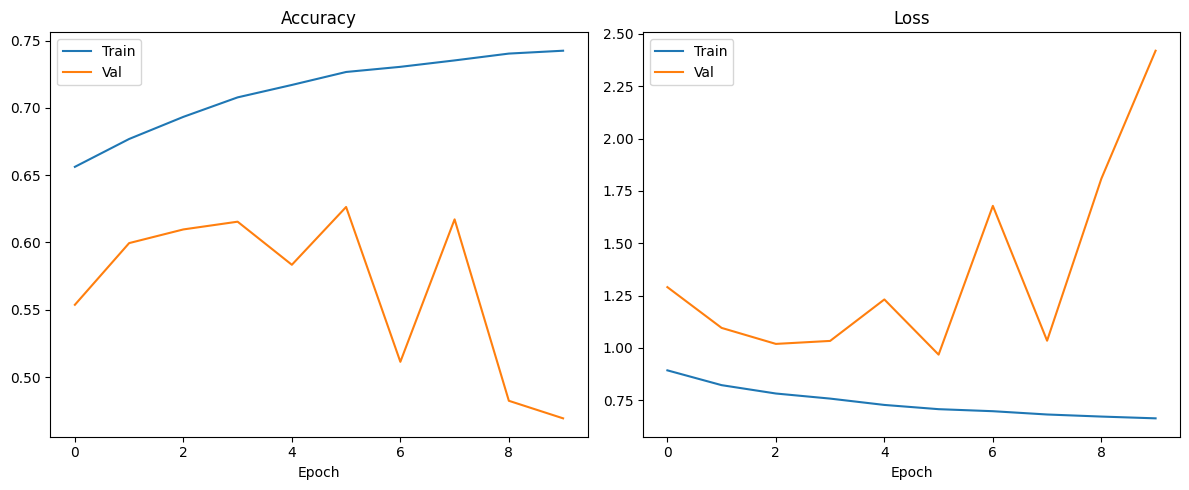

In [24]:

# ── 5‑E  4‑CURVE PLOT (loss & acc) ─────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].plot(hist_reg.history['accuracy'], label='Train')
ax[0].plot(hist_reg.history['val_accuracy'], label='Val')
ax[0].set_title('Accuracy'); ax[0].legend(); ax[0].set_xlabel('Epoch')

ax[1].plot(hist_reg.history['loss'], label='Train')
ax[1].plot(hist_reg.history['val_loss'], label='Val')
ax[1].set_title('Loss'); ax[1].legend(); ax[1].set_xlabel('Epoch')
plt.tight_layout(); plt.savefig("figures/phase5_acc_loss.png", dpi=300); plt.show()

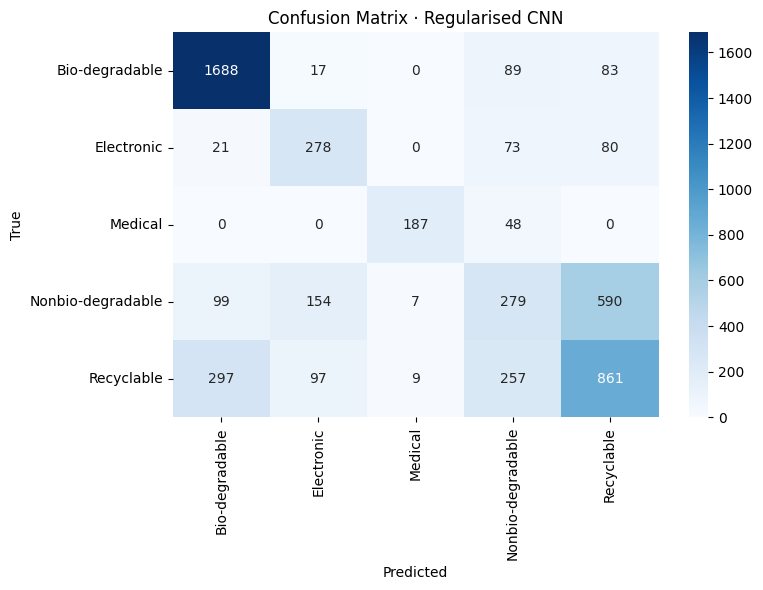

In [25]:

# ── 5‑F  CONFUSION MATRIX ──────────────────────────────────────
val_preds = np.argmax(model_reg.predict(val_gen, verbose=0), axis=1)
true_lbls = val_gen.classes
cm = confusion_matrix(true_lbls, val_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix · Regularised CNN')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.savefig("figures/phase5_confusion.png", dpi=300); plt.show()

In [26]:
# ── 5‑G  SAVE FINAL MODEL ──────────────────────────────────────
model_reg.save("regularised_cnn_final.h5")
print("✅  Phase 5 complete · model saved as regularised_cnn_final.h5")

✅  Phase 5 complete · model saved as regularised_cnn_final.h5


In [27]:
# ── 5‑H  REGULARISATION TABLE (quick printout) ─────────────────
import pandas as pd
reg_table = pd.DataFrame({
    "dropout": [0.5],
    "batch_norm": [True],
    "weight_decay": [1e-4],
    "early_stop_patience": [5]
})
print("\nRegularisation config:\n", reg_table.to_string(index=False))


Regularisation config:
  dropout  batch_norm  weight_decay  early_stop_patience
     0.5        True        0.0001                    5


In [28]:
# ╔════════════════════════════════════════════════════╗
# ║  HELPER · COLLECT REGULARISATION ACCURACIES        ║
# ╚════════════════════════════════════════════════════╝
import pandas as pd, json, pathlib, IPython.display as dsp

if "acc_table_rows" not in globals():
    acc_table_rows = []                       # lives for the whole notebook

def add_result(label:str, history):
    """Call right after model.fit(); label = regularisation type."""
    train_acc = history.history['accuracy'][-1] * 100
    val_acc   = history.history['val_accuracy'][-1] * 100
    acc_table_rows.append({
        "Regularization Method": label,
        "Training Accuracy (%)": f"{train_acc:.1f}",
        "Validation Accuracy (%)": f"{val_acc:.1f}"
    })
    display_table()                           # show & autosave CSV

def display_table():
    df = pd.DataFrame(acc_table_rows)
    dsp.display(df)                           # nice HTML table
    df.to_csv("reg_accuracy_table.csv", index=False)   # for your report


In [35]:
# ╔════════════════════════════════════════════════════╗
# ║  QUICK VARIANT TRAININGS FOR ACCURACY TABLE        ║
# ╚════════════════════════════════════════════════════╝
from tensorflow.keras import layers, models, optimizers, regularizers, callbacks

EPOCHS = 10            # quick run; adjust to 10 for full comparison
L2_VAL = 1e-2          # 0.01, same as your friend’s report
INPUT_SHAPE = (*IMG_SIZE, 3)

def compile_and_train(model, label):
    model.compile(optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    hist = model.fit(train_gen, epochs=EPOCHS, validation_data=val_gen,
                     class_weight=class_weight, verbose=2)
    add_result(label, hist)

# --- 1. Baseline (No Regularization) -----------------
model_base = models.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=INPUT_SHAPE),
    layers.MaxPool2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPool2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPool2D(),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
compile_and_train(model_base, "No Regularization")

# --- 2. Dropout only (0.5) ---------------------------
model_do = models.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=INPUT_SHAPE),
    layers.MaxPool2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPool2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPool2D(),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])
compile_and_train(model_do, "Dropout (0.5)")

# --- 3. L2 Regularization only (λ=0.01) -------------- 
L2 = regularizers.l2(L2_VAL)
model_l2 = models.Sequential([
    layers.Conv2D(32, 3, activation='relu', kernel_regularizer=L2, input_shape=INPUT_SHAPE),
    layers.MaxPool2D(),
    layers.Conv2D(64, 3, activation='relu', kernel_regularizer=L2),
    layers.MaxPool2D(),
    layers.Conv2D(128, 3, activation='relu', kernel_regularizer=L2),
    layers.MaxPool2D(),
    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_regularizer=L2),
    layers.Dense(num_classes, activation='softmax', kernel_regularizer=L2)
])
compile_and_train(model_l2, "L2 Regularization (=0.01)")

# --- 4. Batch Normalization only ---------------------
model_bn = models.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=INPUT_SHAPE),
    layers.BatchNormalization(),
    layers.MaxPool2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPool2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPool2D(),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(num_classes, activation='softmax')
])
compile_and_train(model_bn, "Batch Normalization")

# --- 5. Final regularised model row (already trained) ----
add_result("Dropout+BN+L2 (final)", hist_reg)   # hist_reg from Phase 5

# Table saved to reg_accuracy_table.csv automatically


D:\NNDL\dl_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
924/924 - 351s - 380ms/step - accuracy: 0.5849 - loss: 0.9396 - val_accuracy: 0.5449 - val_loss: 1.0573
Epoch 2/10
924/924 - 343s - 371ms/step - accuracy: 0.6611 - loss: 0.7483 - val_accuracy: 0.5673 - val_loss: 1.1202
Epoch 3/10
924/924 - 342s - 370ms/step - accuracy: 0.6905 - loss: 0.6956 - val_accuracy: 0.5972 - val_loss: 1.0324
Epoch 4/10
924/924 - 341s - 369ms/step - accuracy: 0.7064 - loss: 0.6631 - val_accuracy: 0.5880 - val_loss: 0.9590
Epoch 5/10
924/924 - 342s - 370ms/step - accuracy: 0.7137 - loss: 0.6415 - val_accuracy: 0.5949 - val_loss: 0.9539
Epoch 6/10
924/924 - 341s - 369ms/step - accuracy: 0.7217 - loss: 0.6201 - val_accuracy: 0.6235 - val_loss: 0.9299
Epoch 7/10
924/924 - 460s - 498ms/step - accuracy: 0.7296 - loss: 0.6096 - val_accuracy: 0.6041 - val_loss: 0.8966
Epoch 8/10
924/924 - 353s - 382ms/step - accuracy: 0.7375 - loss: 0.5915 - val_accuracy: 0.6013 - val_loss: 0.9384
Epoch 9/10
924/924 - 345s - 374ms/step - accuracy: 0.7447 - loss: 0.5764 - val_a

,Regularization Method,Training Accuracy (%),Validation Accuracy (%)
0,Dropout+BN+L2 (final),74.3,46.9
1,Regularised CNN (Dropout+BN+L2),74.3,46.9
2,No Regularization,71.7,60.5
3,No Regularization,74.8,62.5


D:\NNDL\dl_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
924/924 - 347s - 375ms/step - accuracy: 0.5499 - loss: 1.0317 - val_accuracy: 0.5504 - val_loss: 1.0824
Epoch 2/10
924/924 - 348s - 376ms/step - accuracy: 0.6504 - loss: 0.7906 - val_accuracy: 0.5568 - val_loss: 1.0546
Epoch 3/10
924/924 - 347s - 375ms/step - accuracy: 0.6777 - loss: 0.7311 - val_accuracy: 0.5608 - val_loss: 1.0027
Epoch 4/10
924/924 - 348s - 377ms/step - accuracy: 0.6902 - loss: 0.6950 - val_accuracy: 0.5829 - val_loss: 0.9756
Epoch 5/10
924/924 - 350s - 378ms/step - accuracy: 0.7021 - loss: 0.6772 - val_accuracy: 0.6003 - val_loss: 0.9936
Epoch 6/10
924/924 - 348s - 376ms/step - accuracy: 0.7132 - loss: 0.6562 - val_accuracy: 0.5934 - val_loss: 0.9586
Epoch 7/10
924/924 - 347s - 376ms/step - accuracy: 0.7171 - loss: 0.6367 - val_accuracy: 0.5995 - val_loss: 1.0137
Epoch 8/10
924/924 - 346s - 375ms/step - accuracy: 0.7248 - loss: 0.6241 - val_accuracy: 0.6143 - val_loss: 0.8994
Epoch 9/10
924/924 - 345s - 374ms/step - accuracy: 0.7289 - loss: 0.6116 - val_a

...

,Regularization Method,Training Accuracy (%),Validation Accuracy (%)
0,Dropout+BN+L2 (final),74.3,46.9
1,Regularised CNN (Dropout+BN+L2),74.3,46.9
2,No Regularization,71.7,60.5
3,No Regularization,74.8,62.5
4,Dropout (0.5),73.7,60.9
5,L2 Regularization (=0.01),66.5,56.8


D:\NNDL\dl_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
924/924 - 677s - 733ms/step - accuracy: 0.6582 - loss: 0.8223 - val_accuracy: 0.4931 - val_loss: 1.3010
Epoch 2/10
924/924 - 679s - 734ms/step - accuracy: 0.7133 - loss: 0.6584 - val_accuracy: 0.6168 - val_loss: 0.9479
Epoch 3/10
924/924 - 732s - 793ms/step - accuracy: 0.7317 - loss: 0.6086 - val_accuracy: 0.5830 - val_loss: 1.1450
Epoch 4/10
924/924 - 628s - 680ms/step - accuracy: 0.7393 - loss: 0.5862 - val_accuracy: 0.5926 - val_loss: 0.9866
Epoch 5/10
924/924 - 618s - 669ms/step - accuracy: 0.7494 - loss: 0.5649 - val_accuracy: 0.5944 - val_loss: 0.9910
Epoch 6/10
924/924 - 629s - 681ms/step - accuracy: 0.7537 - loss: 0.5464 - val_accuracy: 0.6415 - val_loss: 0.8869
Epoch 7/10
924/924 - 611s - 661ms/step - accuracy: 0.7644 - loss: 0.5259 - val_accuracy: 0.6011 - val_loss: 1.1849
Epoch 8/10
924/924 - 623s - 674ms/step - accuracy: 0.7666 - loss: 0.5149 - val_accuracy: 0.6496 - val_loss: 0.8611
Epoch 9/10
924/924 - 621s - 672ms/step - accuracy: 0.7708 - loss: 0.5009 - val_a

,Regularization Method,Training Accuracy (%),Validation Accuracy (%)
0,Dropout+BN+L2 (final),74.3,46.9
1,Regularised CNN (Dropout+BN+L2),74.3,46.9
2,No Regularization,71.7,60.5
3,No Regularization,74.8,62.5
4,Dropout (0.5),73.7,60.9
5,L2 Regularization (=0.01),66.5,56.8
6,Batch Normalization,77.6,56.3


,Regularization Method,Training Accuracy (%),Validation Accuracy (%)
0,Dropout+BN+L2 (final),74.3,46.9
1,Regularised CNN (Dropout+BN+L2),74.3,46.9
2,No Regularization,71.7,60.5
3,No Regularization,74.8,62.5
4,Dropout (0.5),73.7,60.9
5,L2 Regularization (=0.01),66.5,56.8
6,Batch Normalization,77.6,56.3
7,Dropout+BN+L2 (final),74.3,46.9


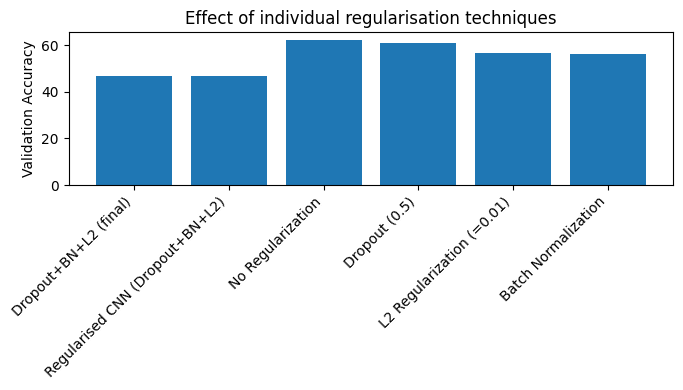

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# load CSV (or use the DataFrame in memory)
df = pd.read_csv("reg_accuracy_table.csv")   # columns: Model, TrainAcc, ValAcc

plt.figure(figsize=(7,4))
plt.bar(df['Regularization Method'], df['Validation Accuracy (%)'])
plt.ylabel("Validation Accuracy")
plt.xticks(rotation=45, ha='right')
plt.title("Effect of individual regularisation techniques")
plt.tight_layout()
plt.show()


In [5]:
# ╔════════════════════════════════════════════════════╗
# ║  STEP 7 : FEATURE EXTRACTION & CLASSICAL MODELS    ║
# ╚════════════════════════════════════════════════════╝
import torch, torchvision, numpy as np, matplotlib.pyplot as plt, os
from torchvision import transforms
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
import pandas as pd
from tqdm import tqdm

# ---------- 7‑A   Paths & label mapping ---------------------------
IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".tif",".tiff"}
TRAIN_DIR = Path(r"D:\NNDL\Dataset\DATASET\TRAIN")
TEST_DIR  = Path(r"D:\NNDL\Dataset\DATASET\TEST")
classes   = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir() or d.is_file()])
cls_to_idx = {
    'Battery': 0, 'Bio-degradable': 1, 'Keyboard': 2, 'Microwave': 3, 'Mobile': 4,
    'Mouse': 5, 'Nonbio-degradable': 6, 'PCB': 7, 'Player': 8, 'Printer': 9,
    'Recyclable': 10, 'Television': 11, 'Washing Machine': 12
}

def iter_images(folder):
    for p in folder.rglob("*"):
        if p.suffix.lower() in IMG_EXTS and p.is_file():
            yield p

def get_label(p):
    while p.parent != TRAIN_DIR and p.parent != TEST_DIR:
        p = p.parent
    return p.name

# ---------- 7‑B   Pretrained ResNet‑18 (remove FC) ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet = torchvision.models.resnet18(weights='IMAGENET1K_V1')
feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1]).to(device)
feature_extractor.eval()

tf = transforms.Compose([
    transforms.Resize((224, 224)),

    # ensure exactly 3 channels (RGB)
    transforms.Lambda(
        lambda t: t.repeat(3, 1, 1) if t.shape[0] == 1 else
                  t[:3, ...]         if t.shape[0] == 4 else
                  t),

    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

@torch.no_grad()
def get_vec(img_path):
    img = torchvision.io.read_image(str(img_path))  # uint8 tensor 0‑255
    img = img.float() / 255.0                       # scale to 0‑1
    img = tf(img).unsqueeze(0).to(device)           # resize + normalize
    vec = feature_extractor(img).squeeze().cpu().numpy()
    return vec.reshape(-1)                          # 512‑D vector


In [41]:
!pip install tqdm


In [3]:
# # ---------- 7‑B   Pretrained ResNet‑18 (remove FC) ----------------
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# resnet = torchvision.models.resnet18(weights='IMAGENET1K_V1')
# feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1]).to(device)
# feature_extractor.eval()

# tf = transforms.Compose([
#     transforms.Resize((224, 224)),

#     # ensure exactly 3 channels (RGB)
#     transforms.Lambda(
#         lambda t: t.repeat(3, 1, 1) if t.shape[0] == 1 else
#                   t[:3, ...]         if t.shape[0] == 4 else
#                   t),

#     transforms.Normalize([0.485, 0.456, 0.406],
#                          [0.229, 0.224, 0.225])
# ])



# @torch.no_grad()
# def get_vec(img_path):
#     img = torchvision.io.read_image(str(img_path))  # uint8 tensor 0‑255
#     img = img.float() / 255.0                       # scale to 0‑1
#     img = tf(img).unsqueeze(0).to(device)           # resize + normalise
#     vec = feature_extractor(img).squeeze().cpu().numpy()
#     return vec.reshape(-1)                          # 512‑D vector


In [5]:
from pathlib import Path
from collections import defaultdict

data_dir = Path("dataset")
all_img_paths = list(data_dir.rglob("*.jpg"))

# Step 1: Determine class labels
class_names = set()
for p in all_img_paths:
    if p.parent.parent == data_dir:
        class_name = p.parent.name               # top-level class (e.g., 'Mechanical')
    else:
        class_name = p.parent.name               # sub-folder class (e.g., 'Battery')
    class_names.add(class_name)

# Step 2: Create mapping
cls_to_idx = {cls_name: idx for idx, cls_name in enumerate(sorted(class_names))}
print(cls_to_idx)


{'Battery': 0, 'Bio-degradable': 1, 'Keyboard': 2, 'Microwave': 3, 'Mobile': 4, 'Mouse': 5, 'Nonbio-degradable': 6, 'PCB': 7, 'Player': 8, 'Printer': 9, 'Recyclable': 10, 'Television': 11, 'Washing Machine': 12}


In [6]:
# ---------- 7‑C   Extract features for TRAIN ----------------------
train_paths = list(TRAIN_DIR.rglob("*.jpg"))

train_feats, train_lbls = [], []

for p in tqdm(train_paths, desc="Extracting TRAIN"):
    vec = get_vec(p)  # 512-D feature vector
    label = None

    # Walk up until we find a known class label
    for ancestor in reversed(p.parts):
        if ancestor in cls_to_idx:
            label = cls_to_idx[ancestor]
            break

    if label is None:
        print(f"⚠️ Warning: Could not find class label for path {p}")
        continue

    train_feats.append(vec)
    train_lbls.append(label)

train_feats = np.stack(train_feats, axis=0)   # shape (N, 512)
train_lbls  = np.array(train_lbls)

print("✅ Feature matrix:", train_feats.shape, "| Labels:", train_lbls.shape)


Extracting TRAIN: 100%|██████████████████████████████████████████████████████████| 31616/31616 [07:09<00:00, 73.63it/s]


✅ Feature matrix: (31616, 512) | Labels: (31616,)


In [7]:
# ---------- 7‑D   (Optional) Extract TEST features ----------------
test_paths = list(TEST_DIR.rglob("*.jpg"))

test_feats, test_lbls = [], []

for p in tqdm(test_paths, desc="Extracting TEST"):
    vec = get_vec(p)  # 512-D feature vector
    label = None

    # Walk up until we find a known class label
    for ancestor in reversed(p.parts):
        if ancestor in cls_to_idx:
            label = cls_to_idx[ancestor]
            break

    if label is None:
        print(f"⚠️ Warning: Could not find class label for path {p}")
        continue

    test_feats.append(vec)
    test_lbls.append(label)

test_feats = np.stack(test_feats, axis=0)  # shape (N, 512)
test_lbls  = np.array(test_lbls)

print("✅ Test Feature matrix:", test_feats.shape, "| Test Labels:", test_lbls.shape)

# Save arrays
np.save("test_features.npy", test_feats)
np.save("test_labels.npy", test_lbls)


Extracting TEST: 100%|█████████████████████████████████████████████████████████████| 5269/5269 [00:58<00:00, 90.71it/s]

✅ Test Feature matrix: (5269, 512) | Test Labels: (5269,)


In [8]:

# ---------- 7‑E   Split for classical ML --------------------------

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
        train_feats, train_lbls, test_size=0.2, stratify=train_lbls, random_state=42)

In [10]:
# ---------- 7‑F   Define & train models ---------------------------
models = {
    "SVM (RBF)": make_pipeline(StandardScaler(), SVC(C=10, gamma='scale')),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=None),
    "k-NN (k=5)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "NaiveBayes": GaussianNB()
}
results = []
for name, clf in models.items():
    clf.fit(X_train, y_train)
    pred = clf.predict(X_val)
    acc  = accuracy_score(y_val, pred)
    results.append((name, acc))
    print(f"{name:15s}  ValAcc: {acc:.3f}")

SVM (RBF)        ValAcc: 0.957
RandomForest     ValAcc: 0.895
k-NN (k=5)       ValAcc: 0.939
NaiveBayes       ValAcc: 0.850


In [9]:
# Assuming X_train, X_test, y_train, y_test are already defined

# Step 1: Scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit and transform training data
X_test_scaled = scaler.transform(X_val)        # Only transform test data

# Step 2: Train Logistic Regression with the updated parameters
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=2000, solver='saga')  # Increase max_iter
logistic_model.fit(X_train_scaled, y_train)

# Step 3: Evaluate the model (you can do this after training)
from sklearn.metrics import accuracy_score

y_pred = logistic_model.predict(X_test_scaled)
accuracy = accuracy_score(y_val, y_pred)

print(f"Logistic Regression Accuracy: {accuracy * 100:.2f}%")


Logistic Regression Accuracy: 92.82%


D:\NNDL\dl_env\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


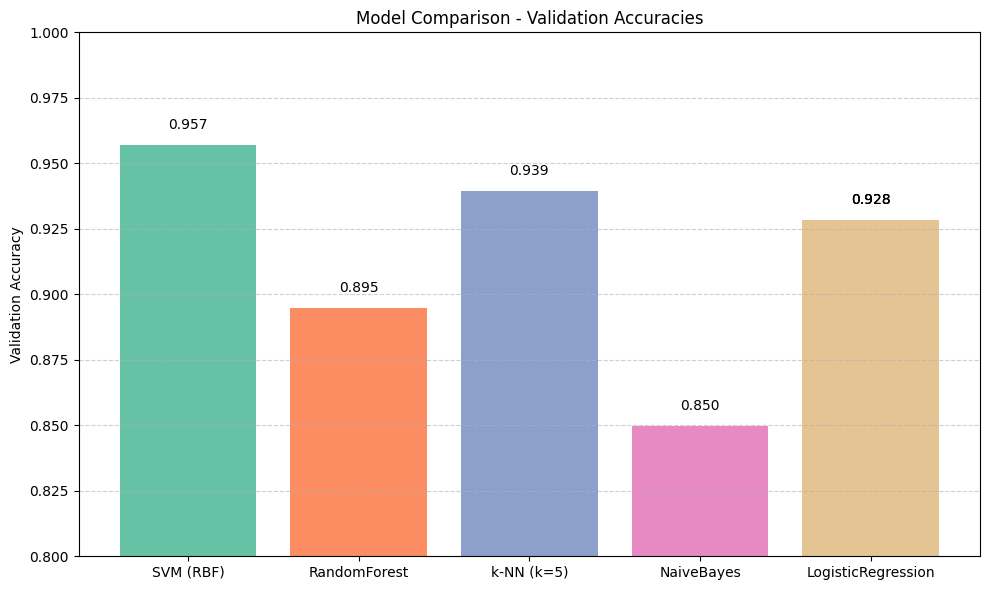

In [14]:
import matplotlib.pyplot as plt

# Add Logistic Regression to results manually
results.append(("LogisticRegression", accuracy))

# Separate names and accuracies
model_names = [name for name, acc in results]
accuracies  = [acc for name, acc in results]

# Define color palette
colors = plt.cm.Set2.colors[:len(results)]  # or use plt.cm.tab10, Set3, etc.

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=colors)
plt.ylim(0.8, 1.0)
plt.ylabel("Validation Accuracy")
plt.title("Model Comparison - Validation Accuracies")
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.005,
             f"{height:.3f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("model_accuracy_comparison.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()



In [2]:
# If you already defined these earlier, just re-run those cells
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define test directory path
TEST_DIR = r"D:\NNDL\Dataset\DATASET\TEST"   # 👈 adjust this if needed

# Image size should match what you used during training
IMG_SIZE = (224, 224)
BATCH_SIZE = 32


Found 6137 images belonging to 5 classes.
192/192 ━━━━━━━━━━━━━━━━━━━━ 66s 345ms/step

✅ CNN Model Performance on TEST Set:
                   precision    recall  f1-score   support

   Bio-degradable       0.74      0.89      0.81      1277
       Electronic       0.79      0.33      0.47       628
          Medical       0.98      0.91      0.95       454
Nonbio-degradable       0.72      0.67      0.69      2188
       Recyclable       0.52      0.62      0.56      1590

         accuracy                           0.68      6137
        macro avg       0.75      0.68      0.70      6137
     weighted avg       0.70      0.68      0.68      6137



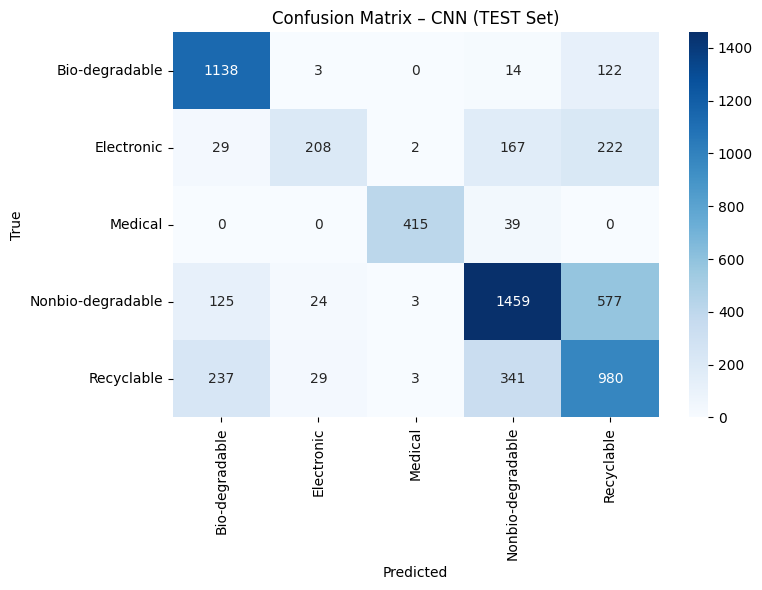

In [6]:
# ╔════════════════════════════════════════════════════╗
# ║  STEP 8 : EVALUATE FINAL CNN ON TEST SET          ║
# ╚════════════════════════════════════════════════════╝
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the trained model
model_cnn = load_model("checkpoints/best_regularised.h5")

# Create a test generator
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# Predict on test set
y_true = test_gen.classes
y_pred_probs = model_cnn.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# Print classification report
print("\n✅ CNN Model Performance on TEST Set:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix – CNN (TEST Set)")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout()
plt.show()


In [2]:
from tensorflow.keras import layers, models, regularizers

def build_regularised(input_shape=(128,128,3), n_classes=5, drop_rate=0.5, weight_decay=1e-4):
    L2 = regularizers.l2(weight_decay)
    model = models.Sequential([
        layers.Conv2D(32, 3, padding='same', kernel_regularizer=L2, activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding='same', kernel_regularizer=L2, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding='same', kernel_regularizer=L2, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dropout(drop_rate),
        layers.Dense(256, activation='relu', kernel_regularizer=L2),
        layers.BatchNormalization(),
        layers.Dropout(drop_rate),
        layers.Dense(n_classes, activation='softmax')
    ])
    return model


Epoch 1/10
924/924 - 787s - 852ms/step - accuracy: 0.5534 - loss: 1.2157 - val_accuracy: 0.3671 - val_loss: 1.8940
Epoch 2/10
924/924 - 752s - 814ms/step - accuracy: 0.6162 - loss: 0.9836 - val_accuracy: 0.4931 - val_loss: 1.3773
Epoch 3/10
924/924 - 771s - 834ms/step - accuracy: 0.6404 - loss: 0.9305 - val_accuracy: 0.5637 - val_loss: 1.1689
Epoch 4/10
924/924 - 769s - 832ms/step - accuracy: 0.6579 - loss: 0.8821 - val_accuracy: 0.3590 - val_loss: 1.7527
Epoch 5/10
924/924 - 777s - 841ms/step - accuracy: 0.6738 - loss: 0.8531 - val_accuracy: 0.5435 - val_loss: 1.2436
Epoch 6/10
924/924 - 780s - 844ms/step - accuracy: 0.6791 - loss: 0.8309 - val_accuracy: 0.5433 - val_loss: 1.1991
Epoch 7/10
924/924 - 781s - 845ms/step - accuracy: 0.6950 - loss: 0.8070 - val_accuracy: 0.5859 - val_loss: 1.0733
Epoch 8/10
924/924 - 781s - 845ms/step - accuracy: 0.7030 - loss: 0.7774 - val_accuracy: 0.4712 - val_loss: 1.6096
Epoch 9/10
924/924 - 780s - 844ms/step - accuracy: 0.7127 - loss: 0.7702 - val_a

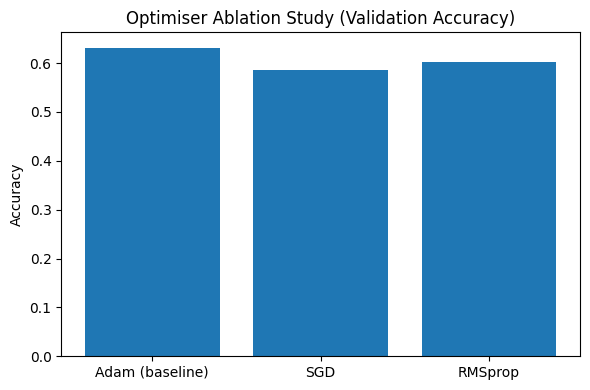

In [10]:
# ╔════════════════════════════════════════════════════╗
# ║  STEP 10: Optimiser Ablation                      ║
# ╚════════════════════════════════════════════════════╝
from tensorflow.keras import optimizers, callbacks
import pandas as pd

# Reuse your model builder from Step 5
def build_regularised_model():
    return build_regularised(input_shape=(128,128,3), n_classes=num_classes,
                             drop_rate=0.5, weight_decay=1e-4)

# Common callback
early_stop = callbacks.EarlyStopping(patience=5, restore_best_weights=True)

def train_with_optimizer(opt, label):
    model = build_regularised_model()
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(
        train_gen,
        epochs=10,
        validation_data=val_gen,
        class_weight=class_weight,
        callbacks=[early_stop],
        verbose=2
    )
    return history, label

# ── Train with SGD ─────────────────────────────
opt_sgd = optimizers.SGD(learning_rate=1e-2, momentum=0.9)
hist_sgd, label_sgd = train_with_optimizer(opt_sgd, "SGD")

# ── Train with RMSprop ─────────────────────────
opt_rms = optimizers.RMSprop(learning_rate=1e-4)
hist_rms, label_rms = train_with_optimizer(opt_rms, "RMSprop")

# ── Collect accuracies ─────────────────────────
results = [
    {"Model": "Adam (baseline)",  "Val Accuracy": max(hist_reg.history['val_accuracy'])},
    {"Model": label_sgd,          "Val Accuracy": max(hist_sgd.history['val_accuracy'])},
    {"Model": label_rms,          "Val Accuracy": max(hist_rms.history['val_accuracy'])}
]

# Save table
df_optim = pd.DataFrame(results)
df_optim.to_csv("optimiser_ablation.csv", index=False)

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.bar(df_optim['Model'], df_optim['Val Accuracy'])
plt.title("Optimiser Ablation Study (Validation Accuracy)")
plt.ylabel("Accuracy") 
plt.tight_layout(); plt.show()


In [11]:
# ╔════════════════════════════════════════════════════╗
# ║ TRANSFER LEARNING: MobileNetV2 + Classifier Head   ║
# ╚════════════════════════════════════════════════════╝
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras import layers, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# --------- A. Parameters -------------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
VAL_SPLIT = 0.15

In [12]:
# --------- B. Data generators --------------------------
train_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1, height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=VAL_SPLIT
)

train_gen = train_aug.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = train_aug.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

Found 29559 images belonging to 5 classes.
Found 5214 images belonging to 5 classes.


In [13]:
# --------- C. Load MobileNetV2 Base (frozen) -----------
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False  # freeze base layers

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [14]:

# --------- D. Add classifier head ----------------------
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(train_gen.num_classes, activation='softmax')(x)

model_tl = Model(inputs=base_model.input, outputs=output)

In [15]:

# --------- E. Compile and callbacks --------------------
model_tl.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early = callbacks.EarlyStopping(patience=5, restore_best_weights=True)

In [16]:
# --------- F. Train the model --------------------------
hist_tl = model_tl.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=[early],
    verbose=2
)

Epoch 1/10
924/924 - 1277s - 1s/step - accuracy: 0.7970 - loss: 0.4826 - val_accuracy: 0.7401 - val_loss: 0.7151
Epoch 2/10
924/924 - 968s - 1s/step - accuracy: 0.8830 - loss: 0.2630 - val_accuracy: 0.7700 - val_loss: 0.6364
Epoch 3/10
924/924 - 915s - 990ms/step - accuracy: 0.8968 - loss: 0.2253 - val_accuracy: 0.7898 - val_loss: 0.5593
Epoch 4/10
924/924 - 912s - 987ms/step - accuracy: 0.9073 - loss: 0.1996 - val_accuracy: 0.7862 - val_loss: 0.5826
Epoch 5/10
924/924 - 910s - 985ms/step - accuracy: 0.9135 - loss: 0.1843 - val_accuracy: 0.8063 - val_loss: 0.4987
Epoch 6/10
924/924 - 941s - 1s/step - accuracy: 0.9198 - loss: 0.1728 - val_accuracy: 0.7956 - val_loss: 0.5180
Epoch 7/10
924/924 - 956s - 1s/step - accuracy: 0.9246 - loss: 0.1624 - val_accuracy: 0.8230 - val_loss: 0.4598
Epoch 8/10
924/924 - 928s - 1s/step - accuracy: 0.9268 - loss: 0.1550 - val_accuracy: 0.8268 - val_loss: 0.4430
Epoch 9/10
924/924 - 930s - 1s/step - accuracy: 0.9284 - loss: 0.1492 - val_accuracy: 0.8377 -

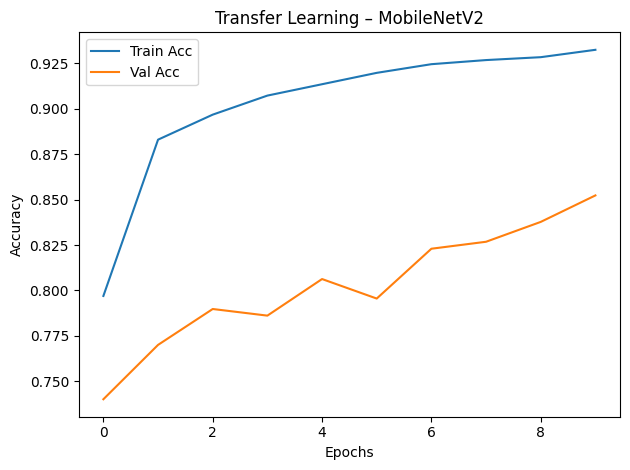

In [17]:

# --------- G. Save model and metrics -------------------
model_tl.save("checkpoints/transfer_mobilenetv2.h5")
pd.DataFrame(hist_tl.history).to_csv("transfer_mobilenet_history.csv", index=False)

# --------- H. Plot accuracy/loss -----------------------
plt.plot(hist_tl.history['accuracy'], label='Train Acc')
plt.plot(hist_tl.history['val_accuracy'], label='Val Acc')
plt.title("Transfer Learning – MobileNetV2")
plt.ylabel("Accuracy"); plt.xlabel("Epochs")
plt.legend(); plt.tight_layout(); plt.show()

In [22]:
# Get final epoch's accuracy
final_train_acc = hist_tl.history['accuracy'][-1]
final_val_acc = hist_tl.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")


Final Training Accuracy: 0.9325
Final Validation Accuracy: 0.8523


In [20]:
# If you already defined these earlier, just re-run those cells
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define test directory path
TEST_DIR = r"D:\NNDL\Dataset\DATASET\TEST"   # 👈 adjust this if needed

# Image size should match what you used during training
IMG_SIZE = (224, 224)
BATCH_SIZE = 32


In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,                      # replace with your actual test directory
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False                  # Important: keep order for predictions
)

test_loss, test_acc = model_tl.evaluate(test_gen, verbose=2)
print(f"✅ MobileNetV2 Test Accuracy: {test_acc:.4f}")


Found 6137 images belonging to 5 classes.
192/192 - 148s - 773ms/step - accuracy: 0.8856 - loss: 0.2995
✅ MobileNetV2 Test Accuracy: 0.8856


Found 29559 images belonging to 5 classes.
Found 5214 images belonging to 5 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


D:\NNDL\dl_env\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
924/924 - 1440s - 2s/step - accuracy: 0.1821 - loss: 1.6147 - val_accuracy: 0.0587 - val_loss: 1.6285
Epoch 2/10
924/924 - 1407s - 2s/step - accuracy: 0.1583 - loss: 1.6095 - val_accuracy: 0.0867 - val_loss: 1.5991
Epoch 3/10
924/924 - 1390s - 2s/step - accuracy: 0.1588 - loss: 1.6100 - val_accuracy: 0.2919 - val_loss: 1.6099
Epoch 4/10
924/924 - 1147s - 1s/step - accuracy: 0.2640 - loss: 1.6092 - val_accuracy: 0.3600 - val_loss: 1.5754
Epoch 5/10
924/924 - 1151s - 1s/step - accuracy: 0.2370 - loss: 1.6095 - val_accuracy: 0.2917 - val_loss: 1.6080
Epoch 6/10
924/924 - 1156s - 1s/step - accuracy: 0.1828 - loss: 1.6092 - val_accuracy: 0.2917 - val_loss: 1.6063
Epoch 7/10
924/924 - 1159s - 1s/step - accuracy: 0.1788 - loss: 1.6090 - val_accuracy: 0.2917 - val_loss: 1.6074
Epoch 8/10
924/924 - 1153s - 1s/step - accuracy: 0.2114 - loss: 1.6085 - val_accuracy: 0.0481 - val_loss: 1.6140
Epoch 9/10
924/924 - 1149s - 1s/step - accuracy: 0.2201 - loss: 1.6085 - val_accuracy: 0.1960 - 

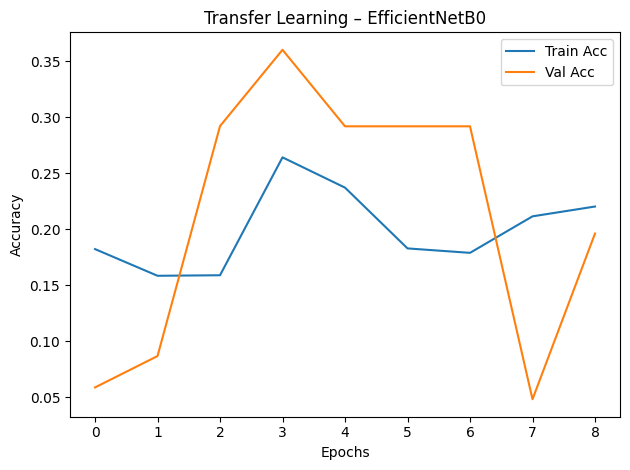

In [2]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras import layers, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# --------- A. Parameters -------------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
VAL_SPLIT = 0.15

# --------- B. Data generators --------------------------
train_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1, height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=VAL_SPLIT
)

train_gen = train_aug.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = train_aug.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

# --------- C. Load EfficientNetB0 Base (frozen) --------
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False  # Freeze base layers

# --------- D. Add classifier head ----------------------
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(train_gen.num_classes, activation='softmax')(x)

model_efn = Model(inputs=base_model.input, outputs=output)

# --------- E. Compile and callbacks --------------------
model_efn.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early = callbacks.EarlyStopping(patience=5, restore_best_weights=True)

# --------- F. Train the model --------------------------
hist_efn = model_efn.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=[early],
    verbose=2
)

# --------- G. Save model and metrics -------------------
model_efn.save("checkpoints/transfer_efficientnetb0.h5")
pd.DataFrame(hist_efn.history).to_csv("transfer_efficientnet_history.csv", index=False)

# --------- H. Plot accuracy/loss -----------------------
plt.plot(hist_efn.history['accuracy'], label='Train Acc')
plt.plot(hist_efn.history['val_accuracy'], label='Val Acc')
plt.title("Transfer Learning – EfficientNetB0")
plt.ylabel("Accuracy"); plt.xlabel("Epochs")
plt.legend(); plt.tight_layout(); plt.show()


In [7]:
# Get final epoch's accuracy
final_train_acc = hist_efn.history['accuracy'][-1]
final_val_acc = hist_efn.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")


Final Training Accuracy: 0.2201
Final Validation Accuracy: 0.1960


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,                      # replace with your actual test directory
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False                  # Important: keep order for predictions
)

test_loss, test_acc = model_efn.evaluate(test_gen, verbose=2)
print(f"✅ EfficientNetBO Test Accuracy: {test_acc:.4f}")


Found 6137 images belonging to 5 classes.
192/192 - 206s - 1s/step - accuracy: 0.2081 - loss: 1.5896
✅ EfficientNetBO Test Accuracy: 0.2081


Found 29559 images belonging to 5 classes.
Found 5214 images belonging to 5 classes.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/10
924/924 - 2762s - 3s/step - accuracy: 0.7620 - loss: 0.5843 - val_accuracy: 0.7484 - val_loss: 0.6845
Epoch 2/10
924/924 - 2159s - 2s/step - accuracy: 0.8724 - loss: 0.2905 - val_accuracy: 0.7768 - val_loss: 0.6156
Epoch 3/10
924/924 - 2186s - 2s/step - accuracy: 0.8925 - loss: 0.2406 - val_accuracy: 0.7984 - val_loss: 0.5417
Epoch 4/10
924/924 - 2194s - 2s/step - accuracy: 0.9029 - loss: 0.2122 - val_accuracy: 0.7904 - val_loss: 0.5576
Epoch 5/10
924/924 - 2192s - 2s/step - accuracy: 0.9086 - loss: 0.1980 - val_accuracy: 0.8166 - val_loss: 0.4771
Epoch 6/10
924/924 - 2193s - 2s/step - accuracy: 0.9128 - loss: 0.1854 - val_accuracy: 0.8272 - val_loss: 0.4572
Epoch 7/10
924/924 - 2158s - 2s/step - accuracy: 0.9182 - loss: 0.1716 - val_accuracy: 0.8232 - val_loss: 0.4711
Epoch 8/10
924/924 - 2389s - 3s/step - accuracy: 0.9217 - loss: 0.1638 - 

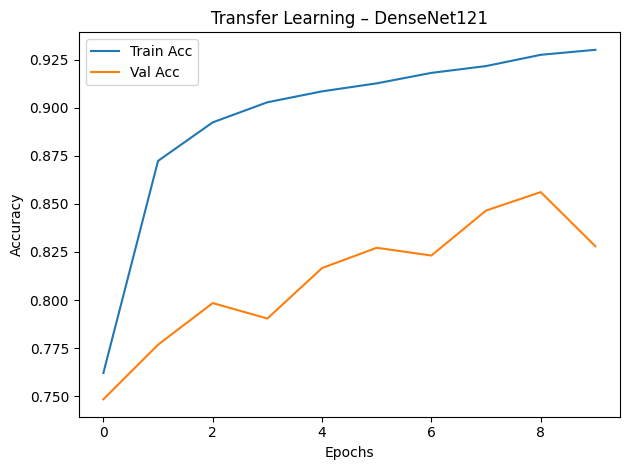

In [3]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras import layers, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# --------- A. Parameters -------------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
VAL_SPLIT = 0.15

# --------- B. Data generators --------------------------
train_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1, height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=VAL_SPLIT
)

train_gen = train_aug.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = train_aug.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

# --------- C. Load DenseNet121 Base (frozen) -----------
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False  # Freeze base layers

# --------- D. Add classifier head ----------------------
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(train_gen.num_classes, activation='softmax')(x)

model_dense = Model(inputs=base_model.input, outputs=output)

# --------- E. Compile and callbacks --------------------
model_dense.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early = callbacks.EarlyStopping(patience=5, restore_best_weights=True)

# --------- F. Train the model --------------------------
hist_dense = model_dense.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=[early],
    verbose=2
)

# --------- G. Save model and metrics -------------------
model_dense.save("checkpoints/transfer_densenet121.h5")
pd.DataFrame(hist_dense.history).to_csv("transfer_densenet_history.csv", index=False)

# --------- H. Plot accuracy/loss -----------------------
plt.plot(hist_dense.history['accuracy'], label='Train Acc')
plt.plot(hist_dense.history['val_accuracy'], label='Val Acc')
plt.title("Transfer Learning – DenseNet121")
plt.ylabel("Accuracy"); plt.xlabel("Epochs")
plt.legend(); plt.tight_layout(); plt.show()


In [4]:
# Get final epoch's accuracy
final_train_acc = hist_dense.history['accuracy'][-1]
final_val_acc = hist_dense.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")


Final Training Accuracy: 0.9302
Final Validation Accuracy: 0.8280


In [5]:
# If you already defined these earlier, just re-run those cells
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define test directory path
TEST_DIR = r"D:\NNDL\Dataset\DATASET\TEST"   # 👈 adjust this if needed

# Image size should match what you used during training
IMG_SIZE = (224, 224)
BATCH_SIZE = 32


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,                      # replace with your actual test directory
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False                  # Important: keep order for predictions
)

test_loss, test_acc = model_dense.evaluate(test_gen, verbose=2)
print(f"✅ DenseNet121 Test Accuracy: {test_acc:.4f}")


Found 6137 images belonging to 5 classes.
192/192 - 476s - 2s/step - accuracy: 0.9042 - loss: 0.2598
✅ DenseNet121 Test Accuracy: 0.9042


Found 29559 images belonging to 5 classes.
Found 5214 images belonging to 5 classes.


D:\NNDL\dl_env\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
924/924 - 1875s - 2s/step - accuracy: 0.3233 - loss: 1.4581 - val_accuracy: 0.3462 - val_loss: 1.4424
Epoch 2/10
924/924 - 1611s - 2s/step - accuracy: 0.3895 - loss: 1.2716 - val_accuracy: 0.3725 - val_loss: 1.3840
Epoch 3/10
924/924 - 1593s - 2s/step - accuracy: 0.4102 - loss: 1.2035 - val_accuracy: 0.3450 - val_loss: 1.4014
Epoch 4/10
924/924 - 1751s - 2s/step - accuracy: 0.4263 - loss: 1.1596 - val_accuracy: 0.3890 - val_loss: 1.3465
Epoch 5/10
924/924 - 1951s - 2s/step - accuracy: 0.4440 - loss: 1.1228 - val_accuracy: 0.4035 - val_loss: 1.3159
Epoch 6/10
924/924 - 1951s - 2s/step - accuracy: 0.4538 - loss: 1.0987 - val_accuracy: 0.3640 - val_loss: 1.3563
Epoch 7/10
924/924 - 1956s - 2s/step - accuracy: 0.4677 - loss: 1.0774 - val_accuracy: 0.3884 - val_loss: 1.3633
Epoch 8/10
924/924 - 2146s - 2s/step - accuracy: 0.4740 - loss: 1.0617 - val_accuracy: 0.3763 - val_loss: 1.3426
Epoch 9/10
924/924 - 1925s - 2s/step - accuracy: 0.4791 - loss: 1.0509 - val_accuracy: 0.4104 - 

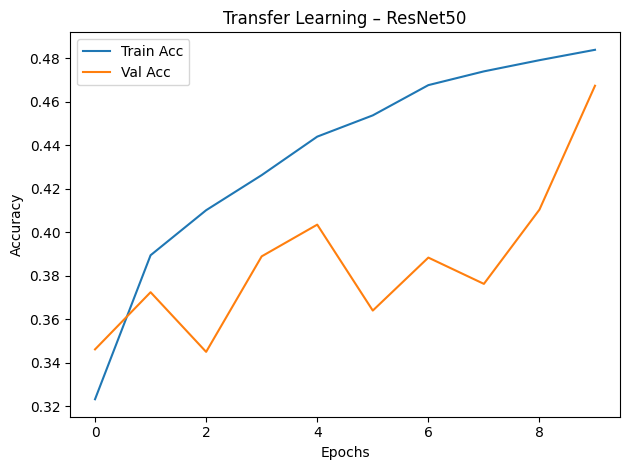

In [2]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras import layers, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import pandas as pd

# --------- A. Parameters -------------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
VAL_SPLIT = 0.15

# --------- B. Data generators --------------------------
train_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1, height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=VAL_SPLIT
)
train_gen = train_aug.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,   
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = train_aug.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

# --------- C. Load ResNet50 Base (frozen) --------------
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False

# --------- D. Add classifier head ----------------------
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(train_gen.num_classes, activation='softmax')(x)

model_resnet = Model(inputs=base_model.input, outputs=output)

# --------- E. Compile and callbacks --------------------
model_resnet.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early = callbacks.EarlyStopping(patience=5, restore_best_weights=True)

# --------- F. Train the model --------------------------
hist_resnet = model_resnet.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=[early],
    verbose=2
)

# --------- G. Save model and metrics -------------------
model_resnet.save("checkpoints/transfer_resnet50.h5")
pd.DataFrame(hist_resnet.history).to_csv("transfer_resnet_history.csv", index=False)  

# --------- H. Plot accuracy/loss -----------------------
plt.plot(hist_resnet.history['accuracy'], label='Train Acc')
plt.plot(hist_resnet.history['val_accuracy'], label='Val Acc')
plt.title("Transfer Learning – ResNet50")
plt.ylabel("Accuracy"); plt.xlabel("Epochs")
plt.legend(); plt.tight_layout(); plt.show()


In [3]:
# Get final epoch's accuracy
final_train_acc = hist_resnet.history['accuracy'][-1]
final_val_acc = hist_resnet.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")


Final Training Accuracy: 0.4839
Final Validation Accuracy: 0.4674


In [4]:
# If you already defined these earlier, just re-run those cells
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define test directory path
TEST_DIR = r"D:\NNDL\Dataset\DATASET\TEST"   # 👈 adjust this if needed

# Image size should match what you used during training
IMG_SIZE = (224, 224)
BATCH_SIZE = 32


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,                      # replace with your actual test directory
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False                  # Important: keep order for predictions
)

test_loss, test_acc = model_resnet.evaluate(test_gen, verbose=2)
print(f"✅ DenseNet121 Test Accuracy: {test_acc:.4f}")


Found 6137 images belonging to 5 classes.
192/192 - 302s - 2s/step - accuracy: 0.5082 - loss: 1.1710
✅ DenseNet121 Test Accuracy: 0.5082


In [2]:
pip install keras-tuner --quiet


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.15

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=VAL_SPLIT
)

train_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

num_classes = train_gen.num_classes


Found 29559 images belonging to 5 classes.
Found 5214 images belonging to 5 classes.


In [5]:
import keras_tuner as kt
from tensorflow.keras import layers, models, optimizers

def build_model(hp):
    model = models.Sequential()

    # Convolutional Layer 1
    model.add(layers.Conv2D(
        filters=hp.Choice('conv_1_filter', values=[32, 64, 128]),
        kernel_size=hp.Choice('conv_1_kernel', values=[3, 5]),
        activation='relu',
        input_shape=(224, 224, 3)
    ))
    model.add(layers.MaxPooling2D())

    # Convolutional Layer 2
    model.add(layers.Conv2D(
        filters=hp.Choice('conv_2_filter', values=[64, 128]),
        kernel_size=hp.Choice('conv_2_kernel', values=[3, 5]),
        activation='relu'
    ))
    model.add(layers.MaxPooling2D())

    model.add(layers.Flatten())

    # Dense Layer
    model.add(layers.Dense(
        units=hp.Choice('dense_units', values=[64, 128, 256]),
        activation='relu'
    ))
    model.add(layers.Dropout(rate=hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)))

    # Output Layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=optimizers.Adam(
            hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='waste_classification_tuning'
)

early_stop = EarlyStopping(monitor='val_loss', patience=3)

tuner.search(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop],
    verbose=2
)


Reloading Tuner from keras_tuner_dir\waste_classification_tuning\tuner0.json

Search: Running Trial #5

Value             |Best Value So Far |Hyperparameter
128               |32                |conv_1_filter
5                 |3                 |conv_1_kernel
128               |128               |conv_2_filter
5                 |5                 |conv_2_kernel
256               |128               |dense_units
0.4               |0.4               |dropout
0.01              |0.0001            |learning_rate




D:\NNDL\dl_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
D:\NNDL\dl_env\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(1)[0]

print("Best hyperparameters:")
for param in best_hps.values.keys():
    print(f"{param}: {best_hps.get(param)}")

# Evaluate and Save
val_loss, val_acc = best_model.evaluate(val_gen)
print(f"Best model validation accuracy: {val_acc:.4f}")

best_model.save("checkpoints/best_hyper_tuned_model.h5")


In [3]:
!pip install lime

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
    --------------------------------------- 0.3/12.9 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.9 MB 1.8 MB/s eta 0:00:07
   --- ------------------------------------ 1.0/12.9 MB 1.8 MB/s eta 0:00:07
   ---- ----------------------------------- 1.6/12.9 MB 2.0 MB/s eta 0:00:06
   ------ --------------------------------- 2.1/12.9 MB 2.1 MB/s eta 0:00:06
   -------- ------------------------------- 2.6/12.9 MB 2.2 MB/s eta 0:00:05
   --------- ------------------------------ 3.1/12.9 MB 2.3 MB/s eta 0:00:05
   ------------ --------------------------- 3.9/12.9 MB 2.4 MB/s eta 0:00:04
   ------------- -------------------------- 4.5/12.9 MB 2.5 MB/s eta 0:00:04
   --------------- ------------------------ 5.0/12.9 MB 2.5 MB/s eta 0:00:04
   ----------------- ---------------------- 5.8/12.9 MB 2.6 MB/s 


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import tensorflow as tf

# Set image size and batch size
img_size = (224, 224)
batch_size = 32

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,            # Your training directory path
    shuffle=True,
    batch_size=batch_size,
    image_size=img_size,
    validation_split=0.2,  # Use 20% of training data as validation
    subset="training",
    seed=123
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    shuffle=True,
    batch_size=batch_size,
    image_size=img_size,
    validation_split=0.2,
    subset="validation",
    seed=123
)


Found 34773 files belonging to 5 classes.
Using 27819 files for training.
Found 34773 files belonging to 5 classes.
Using 6954 files for validation.


In [12]:
import keras_tuner as kt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_model(hp):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base_model.trainable = True
    
    # Tune how many layers to freeze
    freeze_until = hp.Int('freeze_until', min_value=10, max_value=len(base_model.layers), step=10)
    for layer in base_model.layers[:freeze_until]:
        layer.trainable = False
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(hp.Float('dropout', 0.2, 0.5, step=0.1))(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs)
    
    # Tune learning rate
    lr = hp.Float('learning_rate', 1e-5, 1e-3, sampling='log')
    optimizer = Adam(learning_rate=lr)
    
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='my_dir',
    project_name='mobilenetv2_tuning'
)

tuner.search(train_dataset, validation_data=val_dataset, epochs=10)


Reloading Tuner from my_dir\mobilenetv2_tuning\tuner0.json

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
40                |30                |freeze_until
0.3               |0.4               |dropout
0.00097062        |5.133e-05         |learning_rate

Epoch 1/10
870/870 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7457 - loss: 0.6919

KeyboardInterrupt: 

  0%|                                                                                         | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


  1%|▊                                                                               | 10/1000 [00:01<02:21,  7.02it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step


  2%|█▌                                                                              | 20/1000 [00:01<01:15, 13.00it/s]

...

 98%|█████████████████████████████████████████████████████████████████████████████▍ | 980/1000 [00:33<00:00, 30.03it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step


 99%|██████████████████████████████████████████████████████████████████████████████▏| 990/1000 [00:33<00:00, 30.34it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step


100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:33<00:00, 29.64it/s]


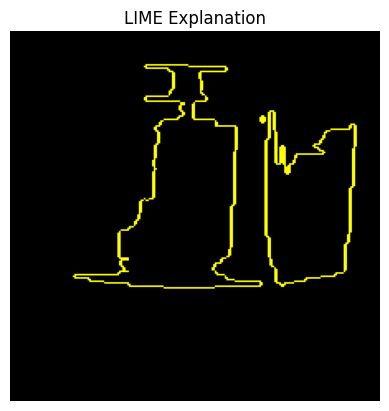

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Suppose this is your trained model
model = tf.keras.models.load_model('checkpoints/transfer_mobilenetv2.h5')  # e.g. model = keras.applications.MobileNetV2(...)

# Define a function for LIME to use for prediction
def predict_fn(images):
    images = np.array(images)
    predictions = model.predict(images)
    return predictions

# Load a sample image and preprocess it
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import cv2

# Load your image (ensure size is correct for MobileNetV2: 224x224)
img_path = 'sample/Microwave_2.jpg'
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = preprocess_input(img_array)  # scale and normalize
img_expanded = np.expand_dims(img_array, axis=0)

# Explain using LIME
explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    image=np.array(img_array).astype('double'),
    classifier_fn=predict_fn,
    top_labels=5,
    hide_color=0,
    num_samples=1000  # more samples = better explanation but slower
)

# Visualize explanation for top label (label=0 means the top predicted class)
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0],
    positive_only=True,
    hide_rest=False,
    num_features=5,
    min_weight=0.0
)

# Show the image with explanation
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title('LIME Explanation')
plt.axis('off')
plt.show()


In [17]:
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries

# Get the image and mask from LIME explanation
image, mask = explanation.get_image_and_mask(
    label,                      # class index to explain
    positive_only=True,        # show only the positive contributions
    num_features=5,            # number of superpixels to highlight
    hide_rest=False            # keep rest of the image visible
)

# Overlay the boundaries on the image
highlighted_image = mark_boundaries(image / 255.0, mask)

# Plot and save
plt.figure(figsize=(6, 6))
plt.imshow(highlighted_image)
plt.axis('off')
plt.title(f'LIME Explanation for class {label}')
plt.savefig('lime_output.png', bbox_inches='tight', pad_inches=0)
plt.close()


In [16]:
# Get the explanation for the top predicted class
label = explanation.top_labels[0]
segments = explanation.segments

# Get the list of (superpixel index, contribution weight)
explanation_list = explanation.local_exp[label]
print(explanation_list)


[(np.int64(0), np.float64(0.005915357914814916)), (np.int64(3), np.float64(-0.00510946621545037)), (np.int64(2), np.float64(-0.0019298063314308746)), (np.int64(1), np.float64(8.28074754164549e-05))]


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,                      # replace with your actual test directory
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False                  # Important: keep order for predictions
)

test_images, test_labels = next(test_gen)


Found 6137 images belonging to 5 classes.


In [9]:
from lime import lime_image
import numpy as np

explainer = lime_image.LimeImageExplainer()

import random
indices = random.sample(range(len(test_images)), 5)
    # same LIME explanation code


# Loop through multiple images
for i in indices:
    image = test_images[i]
    
    # LIME expects input in 4D shape (1, height, width, channels)
    image_np = np.expand_dims(image, axis=0)

    # Get predicted class
    pred_class = np.argmax(model.predict(image_np))

    # Explain prediction
    explanation = explainer.explain_instance(
        image=image.astype('double'),
        classifier_fn=model.predict,
        top_labels=5,
        hide_color=0,
        num_samples=1000
    )

    # Get mask for the predicted class
    temp, mask = explanation.get_image_and_mask(
        label=pred_class,
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    # Save image
    output_name = f'lime_output_image_{i}_class_{pred_class}.png'
    highlighted_image = mark_boundaries(temp / 255.0, mask)
    
    plt.imsave(output_name, highlighted_image)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


  0%|                                                                                         | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step


  1%|▊                                                                               | 10/1000 [00:00<00:49, 19.88it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step


...

 98%|█████████████████████████████████████████████████████████████████████████████▍ | 980/1000 [00:31<00:00, 29.61it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step


 99%|██████████████████████████████████████████████████████████████████████████████▏| 990/1000 [00:32<00:00, 29.95it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step


100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:32<00:00, 30.89it/s]
